# Load packages

In [1]:
import os
import torch
import pandas as pd
import scanpy as sc
import warnings
from muon import prot as pt
import sys
sys.path.append("./model/")
from train import train_SMAHD
from utils import set_seed
set_seed(2025)
warnings.filterwarnings('ignore')
# Environment configuration. SpatialGlue pacakge can be implemented with either CPU or GPU. GPU acceleration is highly recommend for imporoved efficiency.
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# the location of R, which is required for the 'mclust' algorithm. Please replace the path below with local R installation path
os.environ['R_HOME'] = "/usr/lib/R/"

# Load data and construct spatial neighbour graph

In [2]:
data_path="datasets/C04776D6/"
bin_size = 100
adata_RNA = sc.read_h5ad(data_path + 'C04776D6_rna_bin100.h5ad')
adata_ADT = sc.read_h5ad(data_path + 'C04776D6_adt_bin100.h5ad')
print(adata_RNA)
print(adata_ADT)

AnnData object with n_obs × n_vars = 7782 × 29034
    obs: 'orig.ident', 'x', 'y'
    var: 'real_gene_name'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 7782 × 128
    obs: 'orig.ident', 'x', 'y'
    var: 'real_gene_name'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'spatial'


In [3]:
from model.utils import Cal_Spatial_Net
Cal_Spatial_Net(adata_RNA, model="KNN", n_neighbors=8)

The graph contains 62256 edges, 7782 cells.
8.0000 neighbors per cell on average.


# Data pre-processing

In [4]:
# RNA
sc.pp.filter_genes(adata_RNA, min_cells=10)

sc.pp.highly_variable_genes(adata_RNA, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata_RNA, target_sum=1e4)
sc.pp.log1p(adata_RNA)
sc.pp.scale(adata_RNA)
sc.pp.pca(adata_RNA,n_comps=30)
# Protein
adata_ADT.X=adata_ADT.X.astype('float32')
adata_ADT = adata_ADT[adata_RNA.obs_names].copy()
pt.pp.clr(adata_ADT)
sc.pp.scale(adata_ADT)
sc.pp.pca(adata_ADT,n_comps=30)

# Model training and Clustering

In [5]:
adata_list = [adata_RNA]
x = [torch.FloatTensor(adata.obsm["X_pca"].copy()) for adata in adata_list]
edge = torch.LongTensor(adata_RNA.uns["edgeList"])

adata_RNA.obsm["RNA"] = train_SMAHD(
    features=x,
    edge=edge,
    weights=[1, 1],
    emb_dim=32,               
    train_batch_size=5000,   
    infer_batch_size=20000,   
    n_epochs=100,              
    lr=0.01,                   
    weight_decay=1e-6,
    train_device=device,
    infer_device=torch.device('cpu'),
)


Computing METIS partitioning...
Done!
Epoch [100/100]: 100%|██████████| 100/100 [00:27<00:00,  3.65it/s, loss=12.2]


In [6]:
adata_list = [adata_ADT]
x = [torch.FloatTensor(adata.obsm["X_pca"].copy()) for adata in adata_list]
edge = torch.LongTensor(adata_RNA.uns["edgeList"])

adata_ADT.obsm["ADT"] = train_SMAHD(
    features=x,
    edge=edge,
    weights=[1, 1],
    emb_dim=32,               
    train_batch_size=5000,    
    infer_batch_size=20000,   
    n_epochs=100,              
    lr=0.01,                  
    weight_decay=1e-6,
    train_device=device,
    infer_device=torch.device('cpu'),
)

Computing METIS partitioning...
Done!
Epoch [100/100]: 100%|██████████| 100/100 [00:26<00:00,  3.75it/s, loss=4.22]


In [7]:
adata_list = [adata_RNA, adata_ADT]
x = [torch.FloatTensor(adata.obsm["X_pca"].copy()) for adata in adata_list]
edge = torch.LongTensor(adata_RNA.uns["edgeList"])

adata_RNA.obsm["SMAHD"] = train_SMAHD(
    features=x,
    edge=edge,
    weights=[1, 1],
    emb_dim=32,               
    train_batch_size=5000,    
    infer_batch_size=20000,  
    n_epochs=100,               
    lr=0.01,                 
    weight_decay=1e-6,
    train_device=device,
    infer_device=torch.device('cpu'),
)

Computing METIS partitioning...
Done!
Epoch [100/100]: 100%|██████████| 100/100 [00:28<00:00,  3.47it/s, loss=18.2]


In [14]:
sc.pp.neighbors(adata_RNA, use_rep='SMAHD', n_neighbors=15, method='umap')
sc.tl.umap(adata_RNA, min_dist=0.3)

In [8]:
from utils import clustering
from sklearn.metrics import adjusted_rand_score

tool = "mclust"
clustering(adata_RNA, key="SMAHD", add_key="SMAHD_clusters", n_clusters=7, method=tool, use_pca=True)
clustering(adata_RNA, key="RNA", add_key="RNA_clusters", n_clusters=7, method=tool, use_pca=True)
clustering(adata_ADT, key="ADT", add_key="ADT_clusters", n_clusters=7, method=tool, use_pca=True)

   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
fitting ...
  |======================================================================| 100%
fitting ...
  |======================================================================| 100%


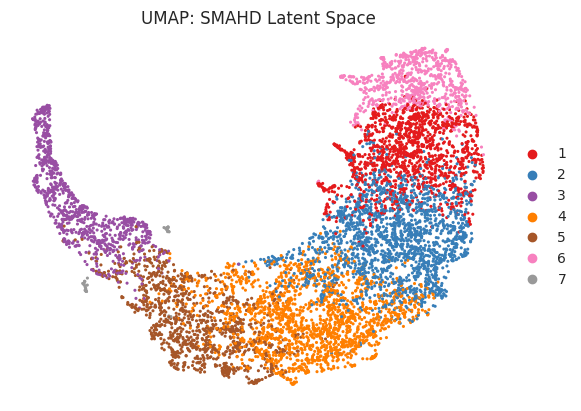

In [15]:
sc.pl.umap(
    adata_RNA, 
    color='SMAHD_clusters', 
    title='UMAP: SMAHD Latent Space',
    s=20,         
    frameon=False, 
    palette='Set1' 
)

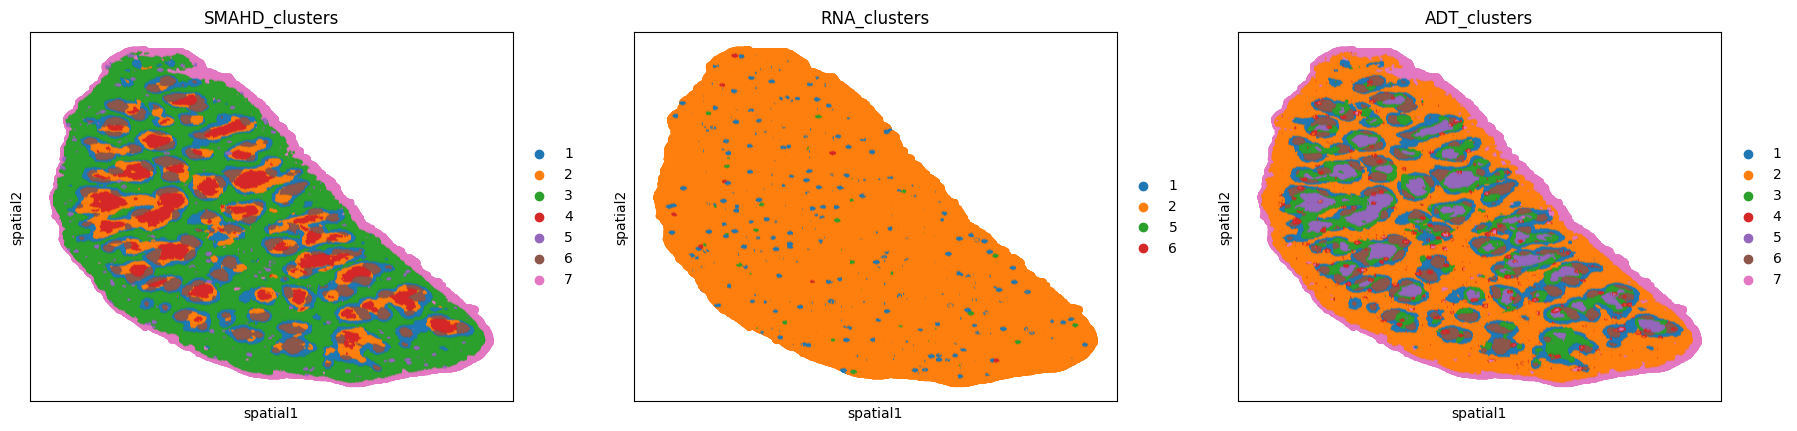

In [11]:
adata_RNA.obs['ADT_clusters'] = adata_ADT.obs['ADT_clusters']
sc.pl.embedding(adata_RNA,basis="spatial",color=['SMAHD_clusters','RNA_clusters','ADT_clusters'],s=50)

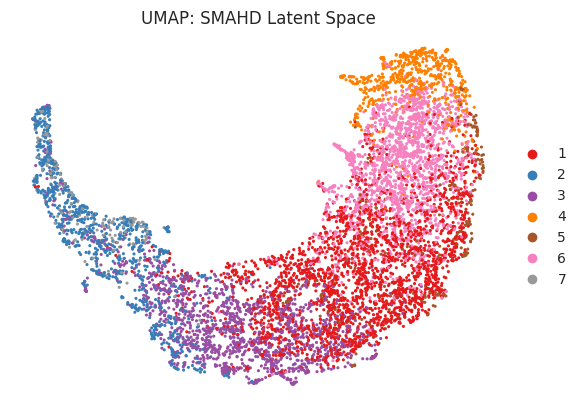

In [17]:
sc.pl.umap(
    adata_RNA, 
    color='RNA_clusters', 
    title='UMAP: RNA Latent Space',
    s=20,         
    frameon=False, 
    palette='Set1' 
)

In [26]:
sc.pp.neighbors(adata_ADT, use_rep='ADT', n_neighbors=15, method='umap')
sc.tl.umap(adata_ADT, min_dist=0.3)

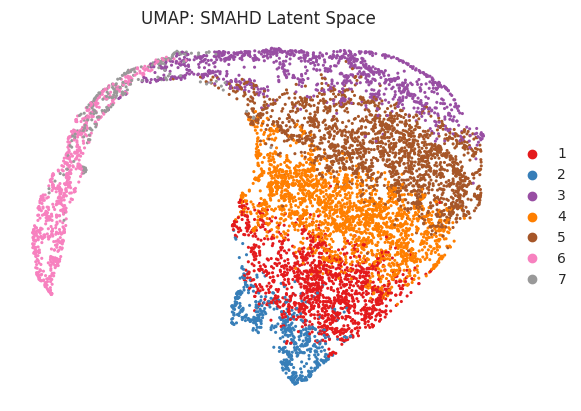

In [27]:
sc.pl.umap(
    adata_ADT, 
    color='ADT_clusters', 
    title='UMAP: SMAHD Latent Space',
    s=20,         
    frameon=False, 
    palette='Set1' 
)

In [28]:
# save_path = "/home/dwang/SMAHD/results/Piaaz_umap/SMAHD.h5ad"
# adata_RNA.write_h5ad(save_path)
# print(f"文件夹已就绪，数据已成功保存至: {save_path}")

文件夹已就绪，数据已成功保存至: /home/dwang/SMAHD/results/Piaaz_umap/SMAHD.h5ad


In [29]:
# save_path = "/home/dwang/SMAHD/results/Piaaz_umap/SMAHD_ADT.h5ad"
# adata_ADT.write_h5ad(save_path)
# print(f"文件夹已就绪，数据已成功保存至: {save_path}")

文件夹已就绪，数据已成功保存至: /home/dwang/SMAHD/results/Piaaz_umap/SMAHD_ADT.h5ad
